# 06 — Structural connectivity perturbation (extension, Part B)

## Motivation

In Notebook 05 (Part A) we built a **virtual lesioning atlas**: for each of the
78 AAL regions we measured how much the best-fit coupling `K*` shifts when we
hide that region from the *comparison* between simulated and empirical PLI.
That ranks regions by how much their functional signatures drive the global
coupling fit — but it never physically touched the brain model. It cannot
distinguish regions whose *anatomical* position is critical from regions whose
*functional* contribution happens to dominate the PLI correlation.

Part B closes that gap. Here we **physically damage the structural
connectivity matrix `W`** by multiplying all incoming and outgoing edges of a
chosen region by `(1 − d)` for damage levels `d ∈ {0, 0.25, 0.5, 0.75, 1.0}`,
then re-run the Hopf simulation on the damaged wiring and refit `K*` against
both the control and glioma empirical PLI. This is a direct in silico lesion
experiment.

## Hypotheses

* **H2** — Damaging the structural connections of a **top driver** from Part A
  produces larger, steeper shifts in `K*` than damaging a **non-driver**
  region. Dose-response slopes should separate the two groups.
* **H2b** — Damaging a top driver in the control simulation pushes
  `K*_control` *upward* toward `K*_glioma`. If it does, anatomical disruption
  alone reproduces the disease-like elevated-coupling signature.

## Continuity with Part A

Everything is kept in the same parameter universe as Notebook 05:

| Thing                    | Value                                          |
|--------------------------|------------------------------------------------|
| SC normalisation         | spectral (unit spectral radius)                |
| λ (excitability)         | `VLA_LAM` from `data/vla_results.npz` (= 40)   |
| K grid                   | `VLA_K` from `data/vla_results.npz`            |
| Simulation settings      | `t_total=8.0, t_discard=1.5, fs=300`           |
| Cortical frequencies     | subject-mean from `exp_frequencies.csv`        |

## Planned figures

1. **Dose–response curves** — `K*` vs damage fraction, one line per region.
2. **Per-region sensitivity** — slope of `K*_ctrl` vs damage; **primary** = mild
   range only (`0 ≤ d ≤ 0.5`, first three damage levels) to avoid
   `d=1` fully disconnecting a node, which is an extreme ablation. A duplicate
   panel saves full-range `0…1` slopes for comparison.
3. **Control-vs-glioma convergence** — `⟨K*_ctrl⟩ − ⟨K*_glio⟩` along damage.
4. **Synthesis vs Part A** — scatter of Part-A `|ΔK|` against Part-B
   **mild-range** structural sensitivity (same as fig 2 primary).

## Robustness (this revision)

* **5 non-drivers** (up from 3) — regions with smallest `|Part-A ΔK|`; better
  power for driver vs null comparisons.
* **50 ICs** per (region, damage) — up from 20; stabilises the mean `K*`
  over the discrete K-grid.
* **Mild-slope** estimates — H2 and the Part A/B synthesis use slopes fit only
  on `d ∈ {0, 0.25, 0.5}`; full `0…1` slopes are saved and plotted in an
  appendix figure for transparency.

## Compute budget

15 regions × 5 damage levels × 50 ICs = **3,750** tasks; each sweeps
`len(VLA_K)` simulations. Expect roughly **~1–1.5 h** on 16 cores (order of
magnitude; depends on load).


In [6]:
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu, spearmanr, wilcoxon

ROOT = Path.cwd()
if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

FIG_DIR = ROOT / "figures" / "hopf model" / "sc perturbation"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from network_analysis import (
    AAL78_LABELS,
    load_cortical_frequencies,
    matrix_correlation,
    normalize_weights,
    simulate_pli_matrix,
)

N_JOBS = int(os.environ.get("HOPF_N_JOBS", "-1"))

%matplotlib inline
plt.rcParams.update({"figure.dpi": 300, "font.size": 11})
RNG = np.random.default_rng(17)

print(f"Parallel workers: N_JOBS={N_JOBS}")
print(f"Figures: {FIG_DIR}")


Parallel workers: N_JOBS=-1
Figures: c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy\figures\hopf model\sc perturbation


## 1. Load empirical data

Spectral-normalised structural connectivity, both cohort PLIs, and the
subject-mean cortical frequencies — identical to Notebook 05.


In [14]:
SC_EMP = normalize_weights(
    np.loadtxt(ROOT / "data" / "structural_connectivity_matrix.csv", delimiter=","),
    method="spectral",
)
CONTROL_PLI = np.loadtxt(ROOT / "data" / "control_PLI_raw.csv", delimiter=",")
GLIOMA_PLI  = np.loadtxt(ROOT / "data" / "glioma_PLI_raw.csv",  delimiter=",")
CORTICAL_FREQ = load_cortical_frequencies(ROOT / "data" / "exp_frequencies.csv")

N_REGIONS = SC_EMP.shape[0]

print(f"SC shape: {SC_EMP.shape}, spectral radius = {np.max(np.abs(np.linalg.eigvalsh(SC_EMP))):.3f}")
print(f"Control PLI: {CONTROL_PLI.shape}, Glioma PLI: {GLIOMA_PLI.shape}")
print(f"Cortical freqs: mean={CORTICAL_FREQ.mean():.2f} Hz, n={CORTICAL_FREQ.size}")


SC shape: (78, 78), spectral radius = 1.000
Control PLI: (78, 78), Glioma PLI: (78, 78)
Cortical freqs: mean=8.32 Hz, n=78


## 2. Load Part A driver rankings

Notebook 05 saved per-region ΔK arrays plus the K-grid and λ it used. We load
those so Part B runs over the **exact same** K values and the **exact same** λ
— the only way the two notebooks' `K*` estimates can be meaningfully compared
in Part C's synthesis figure.


In [15]:
vla = np.load(ROOT / "data" / "vla_results.npz", allow_pickle=True)
print("Keys:", vla.files)

VLA_K   = vla["VLA_K"]
VLA_LAM = float(np.atleast_1d(vla["VLA_LAM"])[0])
mean_ctrl_A = vla["mean_ctrl"]    # per-region Part A ΔK (control)
mean_glio_A = vla["mean_glio"]    # per-region Part A ΔK (glioma)
mean_diff_A = vla["mean_diff"]    # per-region (glioma - control)

print(f"VLA_K: {VLA_K.shape}, range [{VLA_K.min():.2f}, {VLA_K.max():.2f}]")
print(f"VLA_LAM = {VLA_LAM}")
print(f"Part-A per-region ΔK (control): mean={mean_ctrl_A.mean():+.3f}, range=[{mean_ctrl_A.min():+.3f}, {mean_ctrl_A.max():+.3f}]")


Keys: ['dK_ctrl', 'dK_glio', 'dK_diff', 'mean_ctrl', 'mean_glio', 'mean_diff', 'Kfull_ctrl', 'Kfull_glio', 'VLA_K', 'VLA_LAM']
VLA_K: (60,), range [0.50, 50.00]
VLA_LAM = 40.0
Part-A per-region ΔK (control): mean=-0.077, range=[-0.744, +0.417]


## 3. Select regions to perturb

We pick two groups from Part A's control ranking:

* **Top drivers** — the 10 regions whose Part-A virtual lesion produces the
  largest *negative* ΔK (hiding them from the comparison collapses the coupling
  estimate → those regions carry most of the functional weight).
* **Non-drivers** — 5 regions with the smallest |ΔK| in Part A (our null set).
  If damaging them barely moves `K*`, we can claim
  drivers behave *differently* rather than "any damage shifts K*".


In [4]:
N_TOP = 10
N_NULL = 5

order = np.argsort(mean_ctrl_A)  # ascending: most negative ΔK first
TOP_DRIVERS = order[:N_TOP].tolist()

# non-drivers: pick regions near the median absolute ΔK (|ΔK| smallest)
abs_rank = np.argsort(np.abs(mean_ctrl_A))
NON_DRIVERS = abs_rank[:N_NULL].tolist()

REGIONS = TOP_DRIVERS + NON_DRIVERS
REGION_KIND = ["driver"] * N_TOP + ["non-driver"] * N_NULL

print("Top drivers (region : AAL label : Part-A mean ΔK):")
for r in TOP_DRIVERS:
    print(f"  {r:3d}  {AAL78_LABELS[r]:<22s}  {mean_ctrl_A[r]:+.3f}")
print("\nNon-drivers (null group):")
for r in NON_DRIVERS:
    print(f"  {r:3d}  {AAL78_LABELS[r]:<22s}  {mean_ctrl_A[r]:+.3f}")


NameError: name 'mean_ctrl_A' is not defined

## 4. Structural damage model

For a chosen region `r` and damage fraction `d ∈ [0, 1]`, we scale both the
row and the column of `W` corresponding to `r` by `(1 − d)`. This removes
incoming and outgoing connections symmetrically:

* `d = 0.00` → no change
* `d = 0.25` → mild damage
* `d = 0.50` → moderate
* `d = 0.75` → severe
* `d = 1.00` → region anatomically disconnected


In [17]:
def damage_region(W, region, damage_fraction):
    """Scale all edges touching `region` by (1 - damage_fraction)."""
    if damage_fraction <= 0:
        return W
    factor = 1.0 - float(damage_fraction)
    W_dmg = W.copy()
    W_dmg[region, :] *= factor
    W_dmg[:, region] *= factor
    return W_dmg


# sanity check: at d=1, region is fully disconnected; spectral radius should drop
W_test = damage_region(SC_EMP, TOP_DRIVERS[0], 1.0)
print(f"Baseline spectral radius: {np.max(np.abs(np.linalg.eigvalsh(SC_EMP))):.4f}")
print(f"After d=1 on region {TOP_DRIVERS[0]} ({AAL78_LABELS[TOP_DRIVERS[0]]}): "
      f"{np.max(np.abs(np.linalg.eigvalsh(W_test))):.4f}")
print(f"Edges removed: row sum = {W_test[TOP_DRIVERS[0]].sum():.4f}, col sum = {W_test[:, TOP_DRIVERS[0]].sum():.4f}")


Baseline spectral radius: 1.0000
After d=1 on region 34 (Cingulate Post L): 0.9994
Edges removed: row sum = 0.0000, col sum = 0.0000


## 5. K\* fitter for one condition

For a given (region, damage, initial condition) we:

1. Build the damaged `W`.
2. Simulate the Hopf network once for each K in `VLA_K` with λ fixed at
   `VLA_LAM` (same as Part A).
3. Correlate each simulated PLI with **both** empirical PLIs.
4. Take the argmax over K as `K*_ctrl` and `K*_glio`.

This is the same pipeline Part A's `_vla_one_ic` uses, without the per-region
masking — the perturbation lives in `W` now, not in the correlation mask.


In [18]:
def _fit_one(region, damage, ic, W_base, K_vals, lam, freq, emp_ctrl, emp_glio, sim_kw):
    """Return (region, damage, ic, K*_ctrl, K*_glio, corr_ctrl, corr_glio)."""
    seed = 100_000 + region * 1000 + int(round(damage * 100)) * 10 + ic
    W = damage_region(W_base, region, damage)

    n_K = len(K_vals)
    corr_ctrl = np.empty(n_K)
    corr_glio = np.empty(n_K)
    for k, K in enumerate(K_vals):
        pli = simulate_pli_matrix(W, K=K, lam=lam, freq_hz=freq, seed=seed, **sim_kw)
        corr_ctrl[k] = matrix_correlation(pli, emp_ctrl)
        corr_glio[k] = matrix_correlation(pli, emp_glio)

    Kstar_ctrl = K_vals[np.nanargmax(corr_ctrl)]
    Kstar_glio = K_vals[np.nanargmax(corr_glio)]
    return region, float(damage), ic, float(Kstar_ctrl), float(Kstar_glio), corr_ctrl, corr_glio


## 6. Sweep settings

With 15 regions, 5 damage levels, 50 ICs, expect roughly **~1–1.5 h** on a
16-core CPU (rough order of magnitude). K grid and λ stay identical to Part A.


In [19]:
DAMAGE_LEVELS = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
SC_N_IC = 50                                    # ICs averaged per condition (robustness)
DAMAGE_MILD = DAMAGE_LEVELS[:3]                 # 0, 0.25, 0.5  — for mild-slope H2
SC_SIM_KW = dict(t_total=8.0, t_discard=1.5, fs=300)  # matches NB05 VLA_SIM_KW

TASKS = [
    (r, float(d), ic)
    for r in REGIONS
    for d in DAMAGE_LEVELS
    for ic in range(SC_N_IC)
]

n_sims = len(TASKS) * len(VLA_K)
print(f"Regions: {len(REGIONS)} ({N_TOP} drivers + {N_NULL} non-drivers)")
print(f"Damage levels: {DAMAGE_LEVELS.tolist()}")
print(f"ICs per condition: {SC_N_IC}")
print(f"Mild-slope support: d in {DAMAGE_MILD.tolist()}")
print(f"K grid: {VLA_K.size} values, λ = {VLA_LAM}")
print(f"Total tasks: {len(TASKS)}  →  {n_sims} simulations")


Regions: 15 (10 drivers + 5 non-drivers)
Damage levels: [0.0, 0.25, 0.5, 0.75, 1.0]
ICs per condition: 50
Mild-slope support: d in [0.0, 0.25, 0.5]
K grid: 60 values, λ = 40.0
Total tasks: 3750  →  225000 simulations


## 7. Main perturbation sweep

Each task runs one region × damage × IC, sweeping K internally. Parallelised
across tasks with joblib.


In [20]:
print(f"Launching {len(TASKS)} tasks on {N_JOBS} workers ...")
raw = Parallel(n_jobs=N_JOBS, verbose=2)(
    delayed(_fit_one)(
        r, d, ic, SC_EMP, VLA_K, VLA_LAM, CORTICAL_FREQ,
        CONTROL_PLI, GLIOMA_PLI, SC_SIM_KW,
    )
    for (r, d, ic) in TASKS
)

# Reshape into (n_regions, n_damage, n_ic) arrays for K*_ctrl and K*_glio.
n_r, n_d, n_ic = len(REGIONS), len(DAMAGE_LEVELS), SC_N_IC
Kstar_ctrl = np.full((n_r, n_d, n_ic), np.nan)
Kstar_glio = np.full((n_r, n_d, n_ic), np.nan)

region_idx = {r: i for i, r in enumerate(REGIONS)}
damage_idx = {float(d): j for j, d in enumerate(DAMAGE_LEVELS)}

for row in raw:
    r, d, ic, kc, kg, _, _ = row
    i = region_idx[r]; j = damage_idx[float(d)]
    Kstar_ctrl[i, j, ic] = kc
    Kstar_glio[i, j, ic] = kg

mean_Kc = np.nanmean(Kstar_ctrl, axis=2)   # (n_regions, n_damage)
mean_Kg = np.nanmean(Kstar_glio, axis=2)
std_Kc  = np.nanstd(Kstar_ctrl,  axis=2)
std_Kg  = np.nanstd(Kstar_glio,  axis=2)

print("\nBaseline K* (damage=0), control cohort:")
for i, r in enumerate(REGIONS):
    print(f"  {AAL78_LABELS[r]:<22s}  K*_ctrl = {mean_Kc[i, 0]:5.2f},  K*_glio = {mean_Kg[i, 0]:5.2f}")

# Persist for Part C.
out_path = ROOT / "data" / "sc_perturbation_results.npz"
np.savez(
    out_path,
    regions=np.array(REGIONS),
    region_kind=np.array(REGION_KIND),
    damage_levels=DAMAGE_LEVELS,
    Kstar_ctrl=Kstar_ctrl,
    Kstar_glio=Kstar_glio,
    mean_Kc=mean_Kc, mean_Kg=mean_Kg,
    std_Kc=std_Kc,   std_Kg=std_Kg,
    VLA_K=VLA_K, VLA_LAM=np.array([VLA_LAM]),
    mean_ctrl_A=mean_ctrl_A, mean_glio_A=mean_glio_A,
)
print(f"\nSaved {out_path}")


Launching 3750 tasks on -1 workers ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:  8.7min
[Parallel(n_jobs=-1)]: Done 333 tasks      | elapsed: 20.6min
[Parallel(n_jobs=-1)]: Done 616 tasks      | elapsed: 38.1min
[Parallel(n_jobs=-1)]: Done 981 tasks      | elapsed: 61.3min
[Parallel(n_jobs=-1)]: Done 1426 tasks      | elapsed: 89.4min
[Parallel(n_jobs=-1)]: Done 1953 tasks      | elapsed: 123.1min
[Parallel(n_jobs=-1)]: Done 2560 tasks      | elapsed: 161.3min
[Parallel(n_jobs=-1)]: Done 3249 tasks      | elapsed: 203.7min



Baseline K* (damage=0), control cohort:
  Cingulate Post L        K*_ctrl = 35.03,  K*_glio = 36.39
  Frontal Med Orb L       K*_ctrl = 34.76,  K*_glio = 36.27
  Frontal Med Orb R       K*_ctrl = 35.05,  K*_glio = 36.36
  Frontal Sup Med L       K*_ctrl = 34.06,  K*_glio = 36.58
  Frontal Inf Orb L       K*_ctrl = 33.94,  K*_glio = 36.06
  Occipital Inf R         K*_ctrl = 34.39,  K*_glio = 36.79
  Hippocampus L           K*_ctrl = 34.71,  K*_glio = 36.27
  Frontal Sup Med R       K*_ctrl = 35.12,  K*_glio = 36.22
  SMA R                   K*_ctrl = 34.85,  K*_glio = 36.26
  Cuneus R                K*_ctrl = 34.66,  K*_glio = 35.67
  SMA L                   K*_ctrl = 35.12,  K*_glio = 36.41
  Pallidum R              K*_ctrl = 35.07,  K*_glio = 36.16
  Amygdala L              K*_ctrl = 34.76,  K*_glio = 36.14
  Lingual R               K*_ctrl = 34.90,  K*_glio = 36.21
  Precuneus L             K*_ctrl = 34.41,  K*_glio = 36.04

Saved c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practi

[Parallel(n_jobs=-1)]: Done 3750 out of 3750 | elapsed: 235.3min finished


## Rehydrate from cache (skip the sweep)

If the kernel was restarted but `data/sc_perturbation_results.npz` already
exists from a previous run of Cell 15, this cell pulls every array the
figure cells need back into memory so we don't have to re-run the ~1 h
sweep. After running cell 1 (imports + paths), executing this cell alone is
enough to make all four figure cells work.

In [7]:
_cache_path = ROOT / "data" / "sc_perturbation_results.npz"
_cache = np.load(_cache_path, allow_pickle=True)

Kstar_ctrl = _cache["Kstar_ctrl"]
Kstar_glio = _cache["Kstar_glio"]
mean_Kc    = _cache["mean_Kc"]
mean_Kg    = _cache["mean_Kg"]
std_Kc     = _cache["std_Kc"]
std_Kg     = _cache["std_Kg"]

REGIONS       = _cache["regions"].tolist()
REGION_KIND   = _cache["region_kind"].tolist()
DAMAGE_LEVELS = _cache["damage_levels"]
DAMAGE_MILD   = _cache["damage_mild"]
VLA_K         = _cache["VLA_K"]
VLA_LAM       = float(np.atleast_1d(_cache["VLA_LAM"])[0])
N_TOP         = int(np.atleast_1d(_cache["N_TOP"])[0])
N_NULL        = int(np.atleast_1d(_cache["N_NULL"])[0])
SC_N_IC       = int(np.atleast_1d(_cache["SC_N_IC"])[0])
mean_ctrl_A   = _cache["mean_ctrl_A"]
mean_glio_A   = _cache["mean_glio_A"]
mean_diff_A   = mean_glio_A - mean_ctrl_A

slopes_ctrl_mild = _cache["slopes_ctrl_mild"]
slopes_ctrl_full = _cache["slopes_ctrl_full"]
slopes_glio_mild = _cache["slopes_glio_mild"]
slopes_glio_full = _cache["slopes_glio_full"]

n_r, n_d, n_ic = Kstar_ctrl.shape

print(f"Rehydrated from {_cache_path}")
print(f"  Kstar_ctrl: {Kstar_ctrl.shape}   Kstar_glio: {Kstar_glio.shape}")
print(f"  Regions   : {len(REGIONS)} ({N_TOP} drivers + {N_NULL} non-drivers)")
print(f"  Damage    : {DAMAGE_LEVELS.tolist()}   mild = {DAMAGE_MILD.tolist()}")
print(f"  VLA_K     : {VLA_K.size} values, VLA_LAM = {VLA_LAM}")

Rehydrated from c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy\data\sc_perturbation_results.npz
  Kstar_ctrl: (15, 5, 50)   Kstar_glio: (15, 5, 50)
  Regions   : 15 (10 drivers + 5 non-drivers)
  Damage    : [0.0, 0.25, 0.5, 0.75, 1.0]   mild = [0.0, 0.25, 0.5]
  VLA_K     : 60 values, VLA_LAM = 40.0


## Figure 1 — Dose–response curves

Each line is one region's `K*_control` (solid) and `K*_glioma` (dashed) as a
function of structural damage. Drivers are coloured; non-drivers are grey.

**Layman's read.** If a region matters anatomically, cutting its wires should
force the model to crank up the coupling knob `K*` to still match the data.
Steep lines = important region. Flat lines = peripheral region. Non-drivers
(grey) should be our flat baseline.


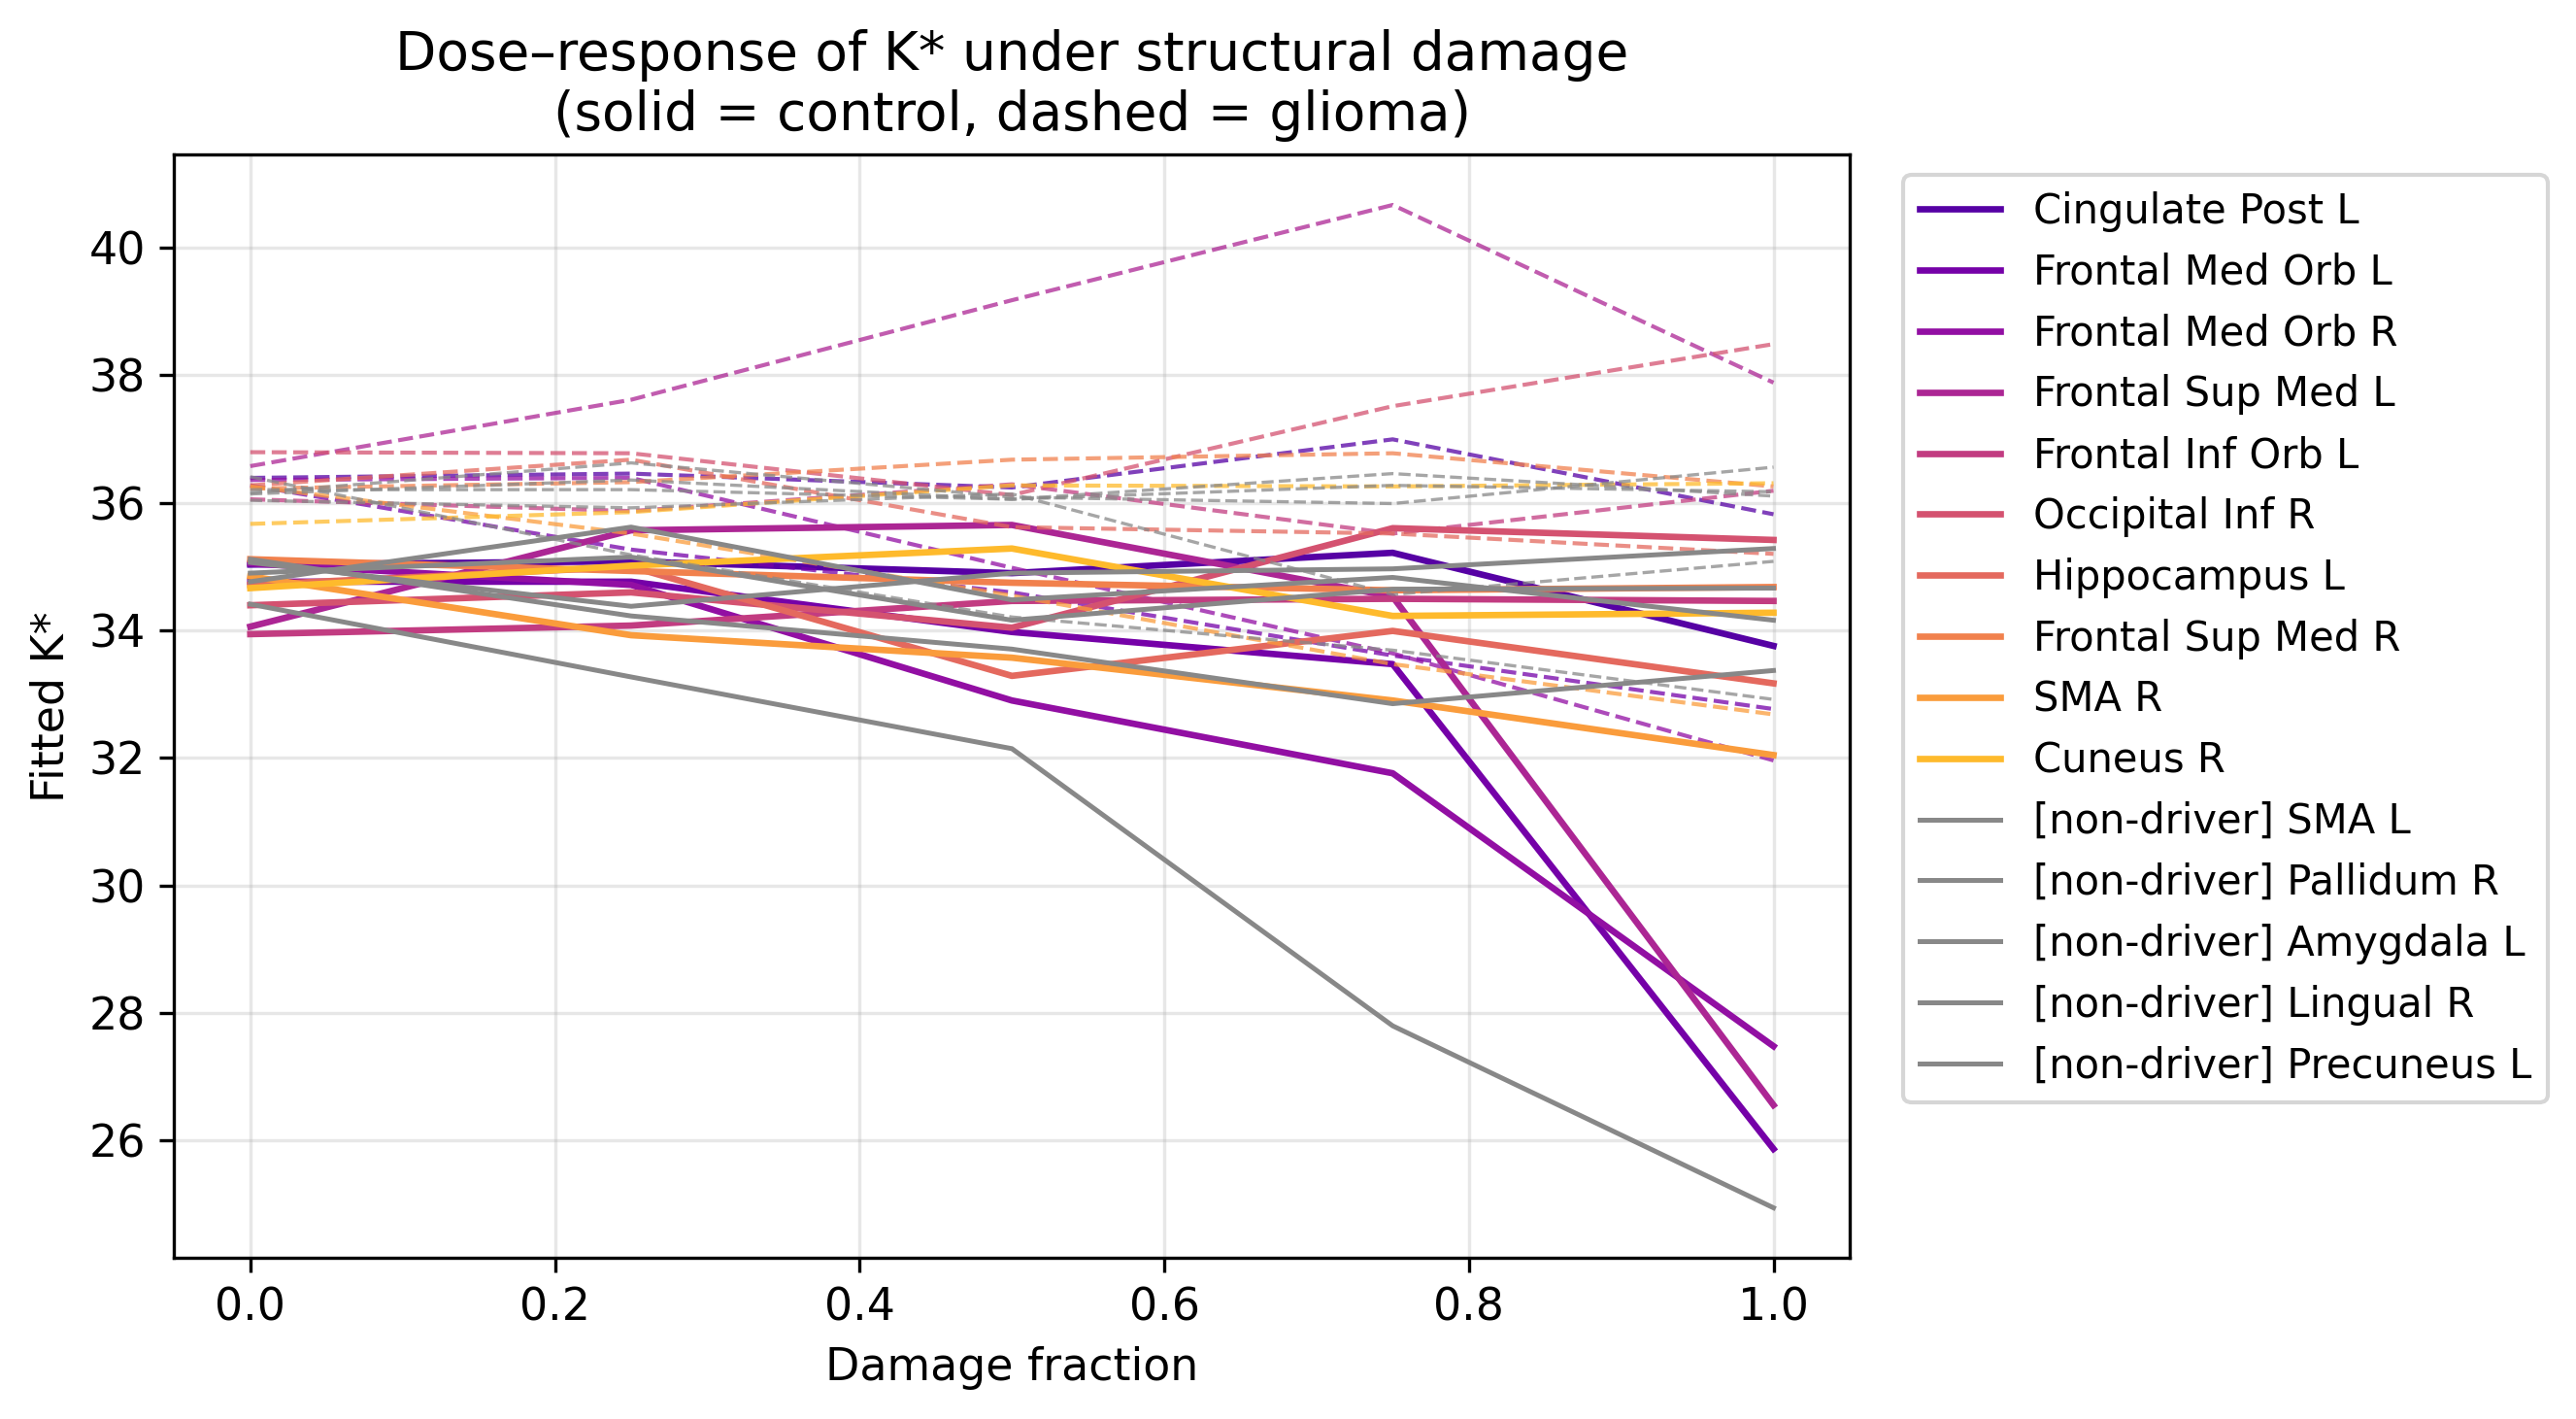

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, N_TOP))

for i, r in enumerate(REGIONS[:N_TOP]):
    ax.plot(DAMAGE_LEVELS, mean_Kc[i], "-",  color=colors[i], lw=1.6,
            label=f"{AAL78_LABELS[r]}")
    ax.plot(DAMAGE_LEVELS, mean_Kg[i], "--", color=colors[i], lw=1.0, alpha=0.75)

for i_rel, r in enumerate(REGIONS[N_TOP:]):
    i = N_TOP + i_rel
    ax.plot(DAMAGE_LEVELS, mean_Kc[i], "-",  color="#888888", lw=1.2,
            label=f"[non-driver] {AAL78_LABELS[r]}")
    ax.plot(DAMAGE_LEVELS, mean_Kg[i], "--", color="#888888", lw=0.8, alpha=0.75)

ax.set_xlabel("Damage fraction")
ax.set_ylabel("Fitted K*")
ax.set_title("Dose–response of K* under structural damage\n(solid = control, dashed = glioma)")
ax.legend(loc="lower right", fontsize=7, ncol=2, framealpha=0.85)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_dose_response.png", dpi=300, bbox_inches="tight")
plt.show()


## Figure 2 — Per-region sensitivity (H2)

**Primary panel** (saved as `fig2_sensitivity_ranked.png`):
least-squares slope of `K*_ctrl` vs damage using only **0 ≤ d ≤ 0.5** (mild
ablation) — avoids the extreme d = 1 full-disconnection case dominating the
slope. **Appendix** (`fig2_sensitivity_full_range.png`): the same for d ∈ [0, 1].

**Expectation under H2.** Drivers (orange) should have systematically larger
slopes than non-drivers (grey). We report a **Wilcoxon** signed-rank test vs the
non-driver median and a **Mann–Whitney** driver vs non-driver comparison.


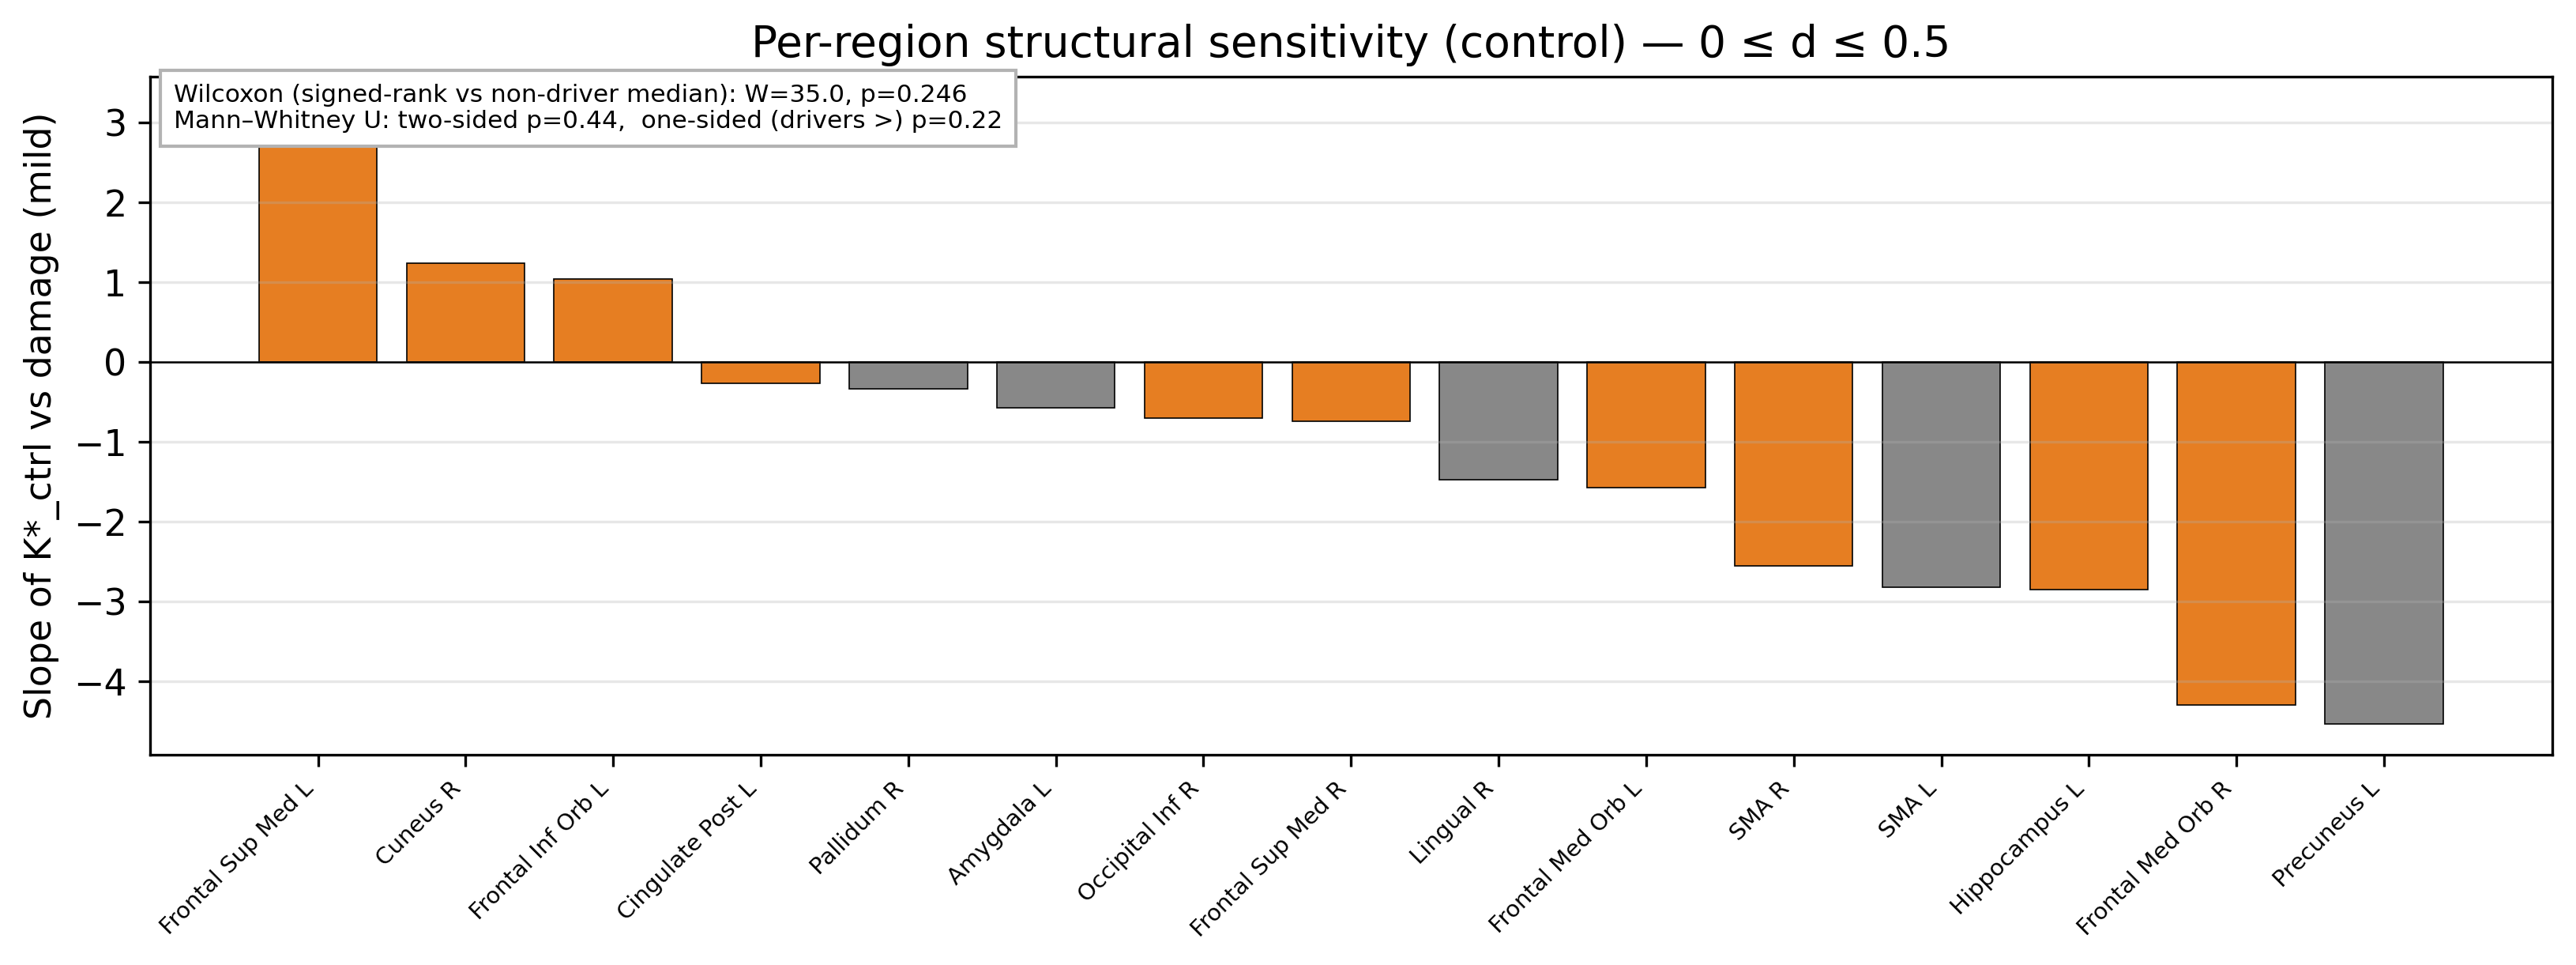

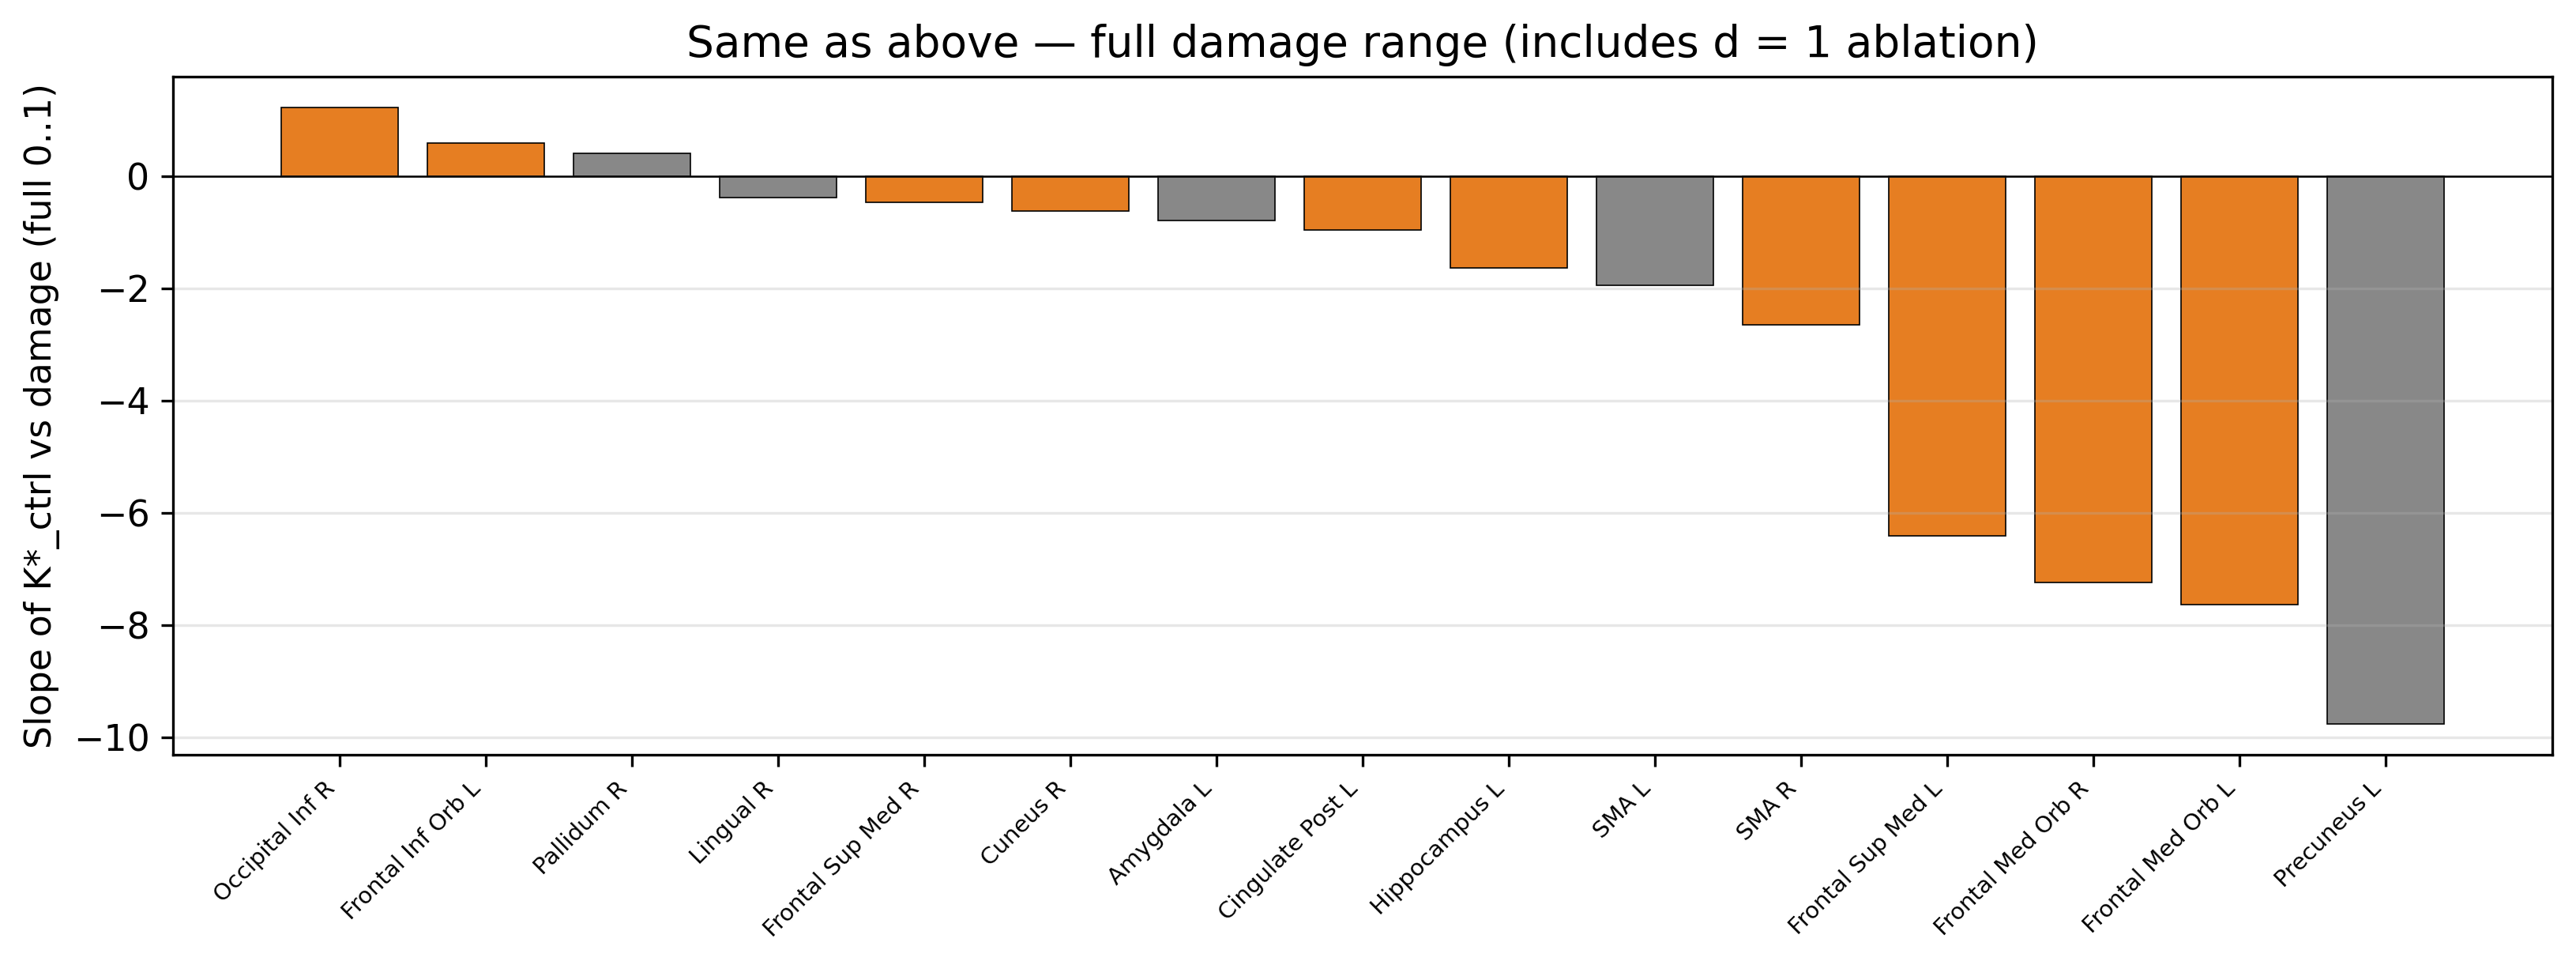

Mild-range slopes  (0–0.5):
  Driver slopes:     mean=-0.752, median=-0.722
  Non-driver slopes: mean=-1.946, median=-1.477
Full-range slopes (0–1):
  Driver slopes:     mean=-2.583, median=-1.302
  Non-driver slopes: mean=-2.497, median=-0.799
Updated (full+slopes): c:\Users\Bob Rice\Desktop\Uni Work\Nottingham\Practical Biomedical Modelling\Functional-connectotomy\data\sc_perturbation_results.npz


In [22]:
# Slopes: full 0..1 (can be dominated by d=1 ablation) and mild 0..0.5 (robustness)
slopes_ctrl_full = np.array([np.polyfit(DAMAGE_LEVELS, mean_Kc[i], 1)[0] for i in range(n_r)])
slopes_glio_full = np.array([np.polyfit(DAMAGE_LEVELS, mean_Kg[i], 1)[0] for i in range(n_r)])
slopes_ctrl_mild = np.array([np.polyfit(DAMAGE_MILD, mean_Kc[i, :3], 1)[0] for i in range(n_r)])
slopes_glio_mild = np.array([np.polyfit(DAMAGE_MILD, mean_Kg[i, :3], 1)[0] for i in range(n_r)])

# Primary H2 / Part-C statistic: mild-range control slopes
slopes_ctrl = slopes_ctrl_mild
slopes_glio = slopes_glio_mild

drv = np.array(REGION_KIND) == "driver"
nul = ~drv

# --- Fig 2a: mild (primary) -------------------------------------------------
order_m = np.argsort(slopes_ctrl_mild)[::-1]
fig, ax = plt.subplots(figsize=(11, 4.2))
xs = np.arange(n_r)
bar_colors = ["#E67E22" if REGION_KIND[i] == "driver" else "#888888" for i in order_m]
ax.bar(xs, slopes_ctrl_mild[order_m], color=bar_colors, edgecolor="black", lw=0.4)
ax.set_xticks(xs)
ax.set_xticklabels([AAL78_LABELS[REGIONS[i]] for i in order_m],
                   rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Slope of K*_ctrl vs damage (mild)")
ax.set_title("Per-region structural sensitivity (control) — 0 ≤ d ≤ 0.5")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0, color="black", lw=0.6)

nd_med = np.median(slopes_ctrl_mild[nul])
try:
    W_stat, p_w = wilcoxon(
        slopes_ctrl_mild[drv] - nd_med, alternative="greater", zero_method="wilcox"
    )
    stat_w = f"Wilcoxon (signed-rank vs non-driver median): W={W_stat:.1f}, p={p_w:.3g}"
except Exception as exc:
    stat_w = f"Wilcoxon: {exc}"

U, p_mw = mannwhitneyu(
    slopes_ctrl_mild[drv], slopes_ctrl_mild[nul], alternative="two-sided"
)
_, p_g = mannwhitneyu(
    slopes_ctrl_mild[drv], slopes_ctrl_mild[nul], alternative="greater"
)
stat_mw = f"Mann–Whitney U: two-sided p={p_mw:.3g},  one-sided (drivers >) p={p_g:.3g}"

ax.text(0.01, 0.99, stat_w + "\n" + stat_mw, transform=ax.transAxes, fontsize=7.5, va="top",
        bbox=dict(facecolor="white", edgecolor="0.7"))

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_sensitivity_ranked.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Fig 2b: full range (appendix) ----------------------------------------
order_f = np.argsort(slopes_ctrl_full)[::-1]
fig, ax = plt.subplots(figsize=(11, 4.2))
bar_colors = ["#E67E22" if REGION_KIND[i] == "driver" else "#888888" for i in order_f]
ax.bar(np.arange(n_r), slopes_ctrl_full[order_f], color=bar_colors, edgecolor="black", lw=0.4)
ax.set_xticks(np.arange(n_r))
ax.set_xticklabels([AAL78_LABELS[REGIONS[i]] for i in order_f],
                   rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Slope of K*_ctrl vs damage (full 0..1)")
ax.set_title("Same as above — full damage range (includes d = 1 ablation)")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0, color="black", lw=0.6)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_sensitivity_full_range.png", dpi=300, bbox_inches="tight")
plt.show()

print("Mild-range slopes  (0–0.5):")
print(f"  Driver slopes:     mean={slopes_ctrl_mild[drv].mean():+.3f}, median={np.median(slopes_ctrl_mild[drv]):+.3f}")
print(f"  Non-driver slopes: mean={slopes_ctrl_mild[nul].mean():+.3f}, median={nd_med:+.3f}")
print("Full-range slopes (0–1):")
print(f"  Driver slopes:     mean={slopes_ctrl_full[drv].mean():+.3f}, median={np.median(slopes_ctrl_full[drv]):+.3f}")
print(f"  Non-driver slopes: mean={slopes_ctrl_full[nul].mean():+.3f}, median={np.median(slopes_ctrl_full[nul]):+.3f}")

# Extended save for Part C (overwrites with slope arrays + metadata)
out_path = ROOT / "data" / "sc_perturbation_results.npz"
np.savez(
    out_path,
    regions=np.array(REGIONS),
    region_kind=np.array(REGION_KIND),
    damage_levels=DAMAGE_LEVELS,
    damage_mild=DAMAGE_MILD,
    Kstar_ctrl=Kstar_ctrl,
    Kstar_glio=Kstar_glio,
    mean_Kc=mean_Kc, mean_Kg=mean_Kg,
    std_Kc=std_Kc, std_Kg=std_Kg,
    slopes_ctrl_mild=slopes_ctrl_mild,
    slopes_ctrl_full=slopes_ctrl_full,
    slopes_glio_mild=slopes_glio_mild,
    slopes_glio_full=slopes_glio_full,
    N_TOP=np.array([N_TOP]), N_NULL=np.array([N_NULL]), SC_N_IC=np.array([SC_N_IC]),
    VLA_K=VLA_K, VLA_LAM=np.array([VLA_LAM]),
    mean_ctrl_A=mean_ctrl_A, mean_glio_A=mean_glio_A,
)
print(f"Updated (full+slopes): {out_path}")


## Figure 3 — Control → glioma convergence (H2b)

For each damage level we plot the cohort-mean gap `⟨K*_ctrl⟩ − ⟨K*_glio⟩`
averaged over the driver group. If the gap shrinks as damage grows, damaging
driver anatomy pushes the healthy simulation *toward* the disease regime —
the mechanistic statement Part B was set up to test.


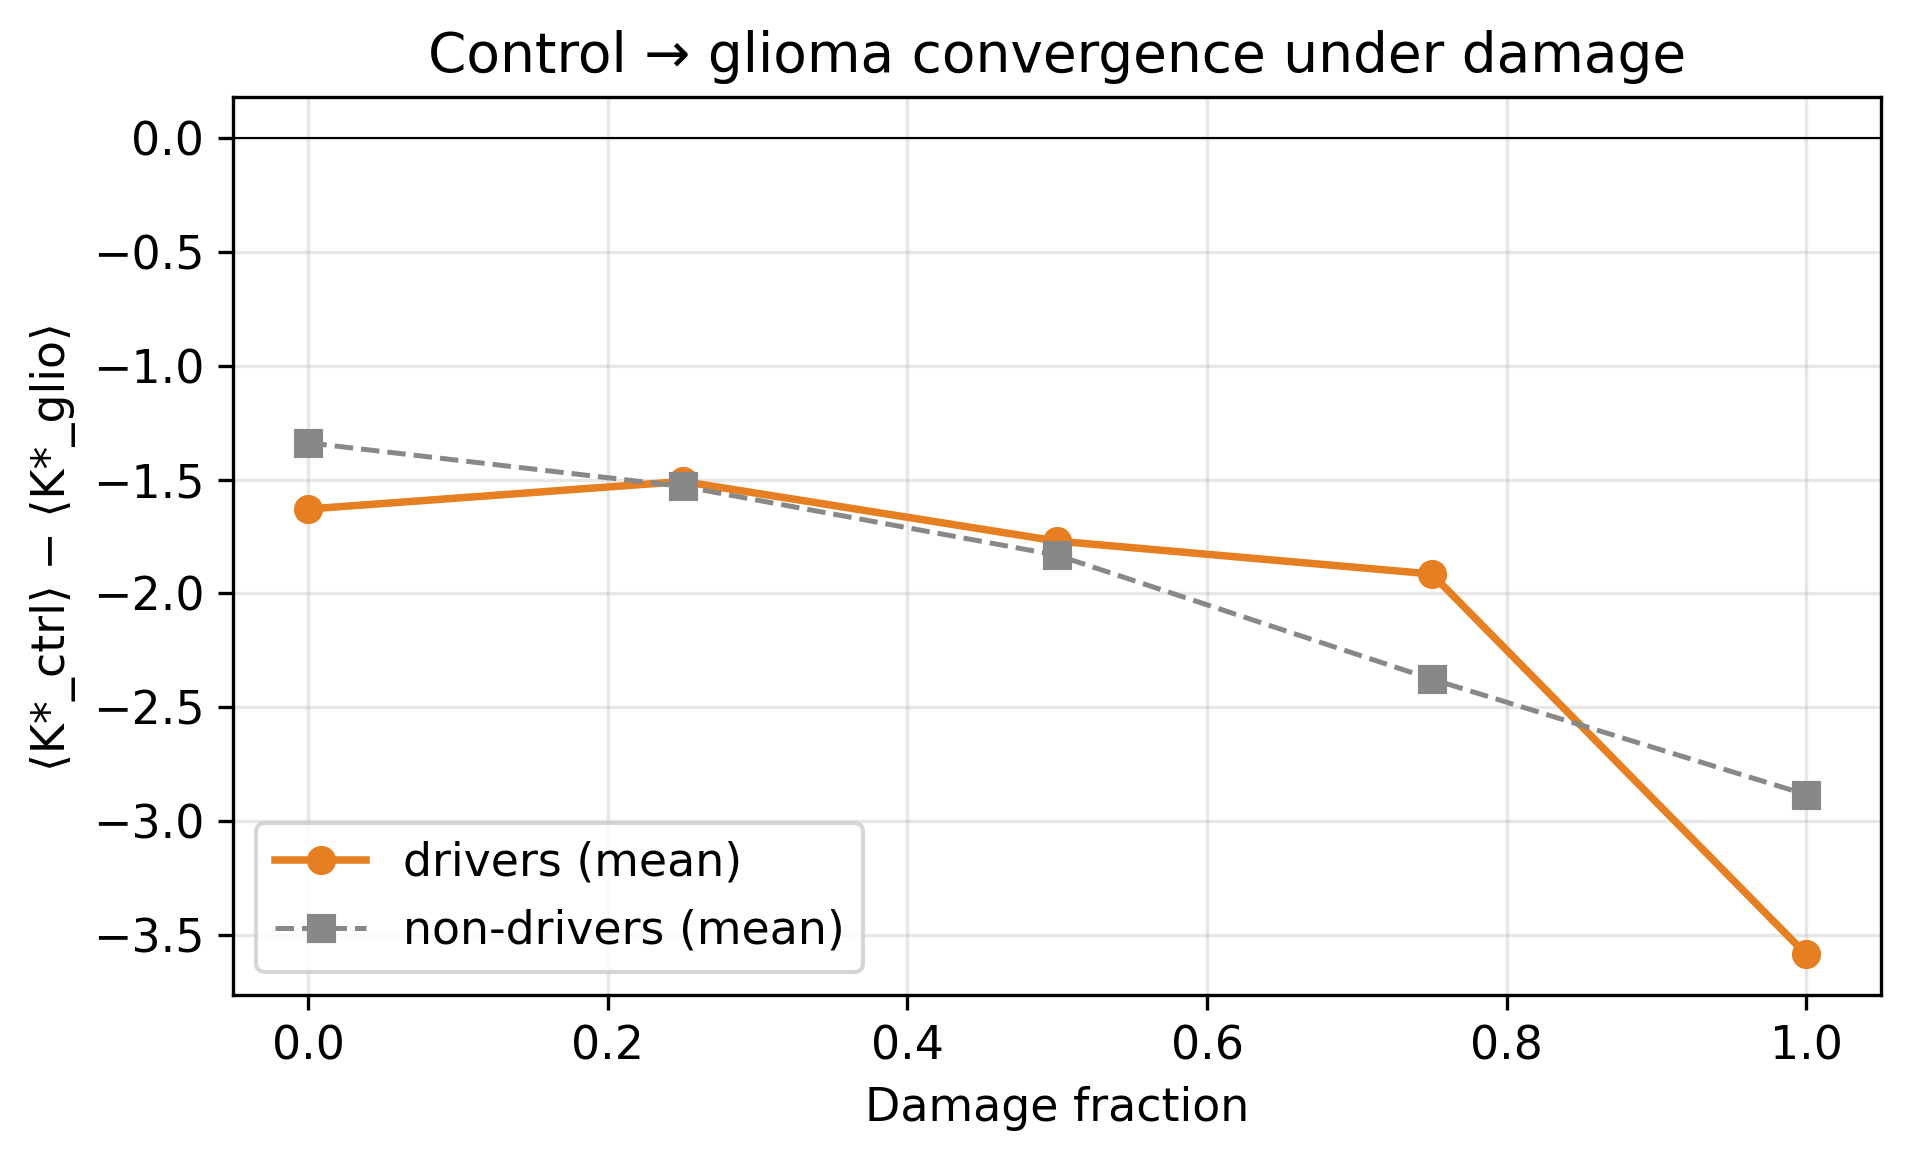

H2b / convergence (all damage levels):
  Baseline gap (drivers)     : -1.629
  At d=0.5 (drivers)         : -1.770  (Δ from baseline: -0.141)
  Full-damage gap (drivers): -3.584  (Δ from baseline: -1.955)
  Baseline gap (non-drvs)    : -1.339
  At d=0.5 (non-drvs)        : -1.832
  Full-damage gap (non-drv)  : -2.883


In [26]:
gap_drv = (mean_Kc[drv].mean(axis=0) - mean_Kg[drv].mean(axis=0))
gap_nul = (mean_Kc[nul].mean(axis=0) - mean_Kg[nul].mean(axis=0))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(DAMAGE_LEVELS, gap_drv, "o-", color="#E67E22", lw=1.8, label="drivers (mean)")
ax.plot(DAMAGE_LEVELS, gap_nul, "s--", color="#888888", lw=1.2, label="non-drivers (mean)")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Damage fraction")
ax.set_ylabel("⟨K*_ctrl⟩ − ⟨K*_glio⟩")
ax.set_title("Control → glioma convergence under damage")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

print("H2b / convergence (all damage levels):")
print(f"  Baseline gap (drivers)     : {gap_drv[0]:+.3f}")
print(f"  At d=0.5 (drivers)         : {gap_drv[2]:+.3f}  (Δ from baseline: {gap_drv[2] - gap_drv[0]:+.3f})")
print(f"  Full-damage gap (drivers): {gap_drv[-1]:+.3f}  (Δ from baseline: {gap_drv[-1] - gap_drv[0]:+.3f})")
print(f"  Baseline gap (non-drvs)    : {gap_nul[0]:+.3f}")
print(f"  At d=0.5 (non-drvs)        : {gap_nul[2]:+.3f}")
print(f"  Full-damage gap (non-drv)  : {gap_nul[-1]:+.3f}")


## Figure 4 — Synthesis: Part A vs Part B (H3)

The money plot. For each region we have:

* **Part A importance** — `|mean_ctrl_A|`, how much hiding the region hurts
  the functional fit.
* **Part B sensitivity** — mild-range slope of `K*_ctrl` (0 ≤ d ≤ 0.5); the
  title also shows Spearman for full-range 0…1 for comparison.

If the two agree (Spearman ρ ≫ 0), the same regions are *both* functionally
dominant and anatomically critical — the synthesis Part C is built on.


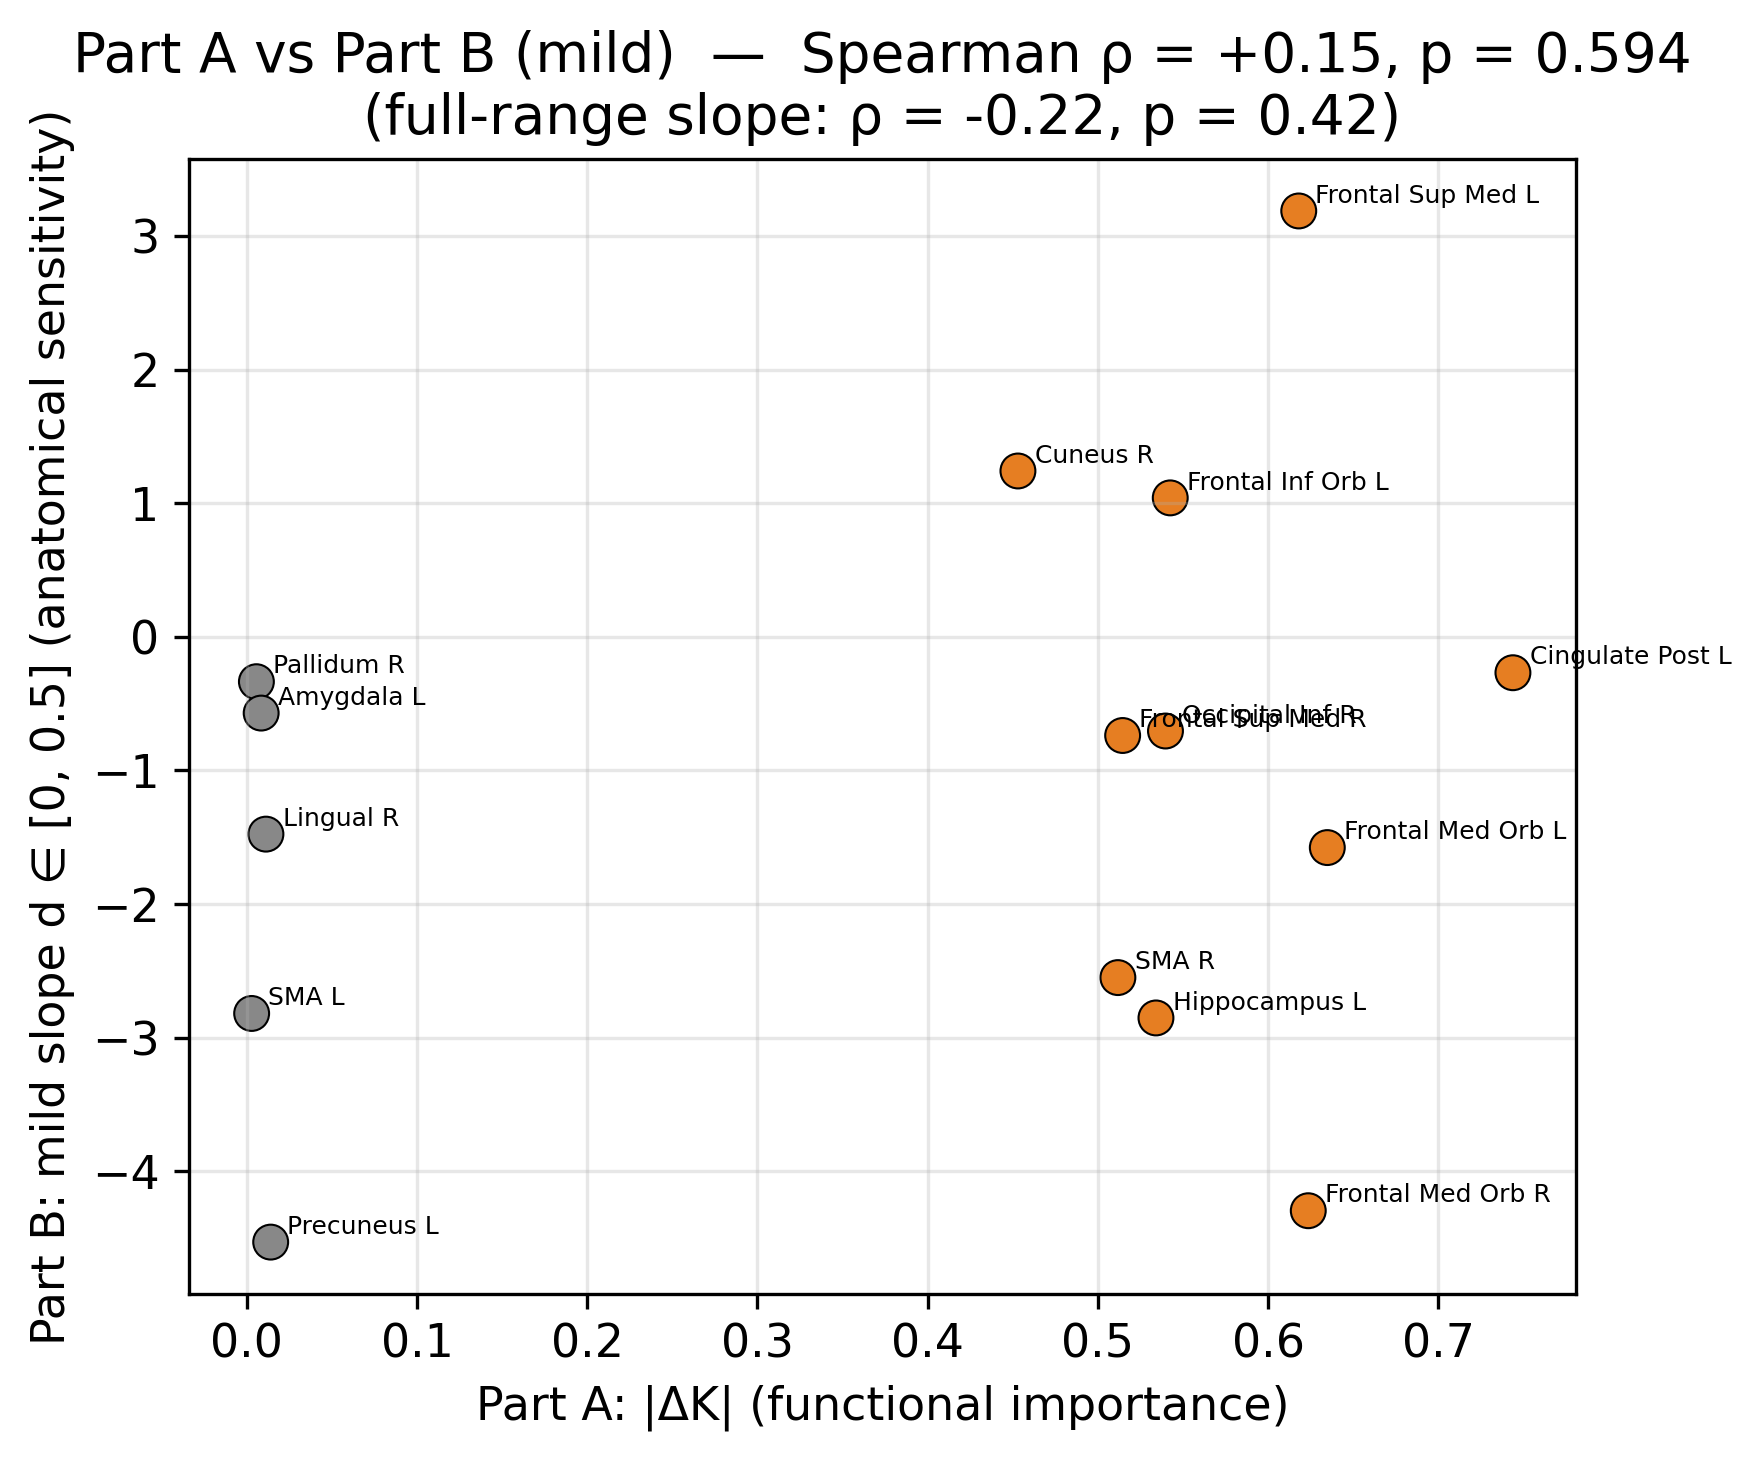

Spearman Part A |ΔK| vs mild slope:   rho=+0.150, p=0.594
Spearman Part A |ΔK| vs full slope:  rho=-0.225, p=0.42


In [24]:
partA = np.abs(mean_ctrl_A[REGIONS])   # Part A magnitude per tested region
# Part B: use mild structural sensitivity (same as primary Fig 2)
partB = slopes_ctrl_mild

rho, pval = spearmanr(partA, partB)
rho_f, p_f = spearmanr(partA, slopes_ctrl_full)

fig, ax = plt.subplots(figsize=(6, 5))
colors_pt = ["#E67E22" if k == "driver" else "#888888" for k in REGION_KIND]
ax.scatter(partA, partB, c=colors_pt, s=70, edgecolor="black", lw=0.5)
for i, r in enumerate(REGIONS):
    ax.annotate(AAL78_LABELS[r], (partA[i], partB[i]), fontsize=6,
                xytext=(4, 2), textcoords="offset points")

ax.set_xlabel("Part A: |ΔK| (functional importance)")
ax.set_ylabel("Part B: mild slope d ∈ [0, 0.5] (anatomical sensitivity)")
ax.set_title(
    f"Part A vs Part B (mild)  —  Spearman ρ = {rho:+.2f}, p = {pval:.3g}\n"
    f"(full-range slope: ρ = {rho_f:+.2f}, p = {p_f:.3g})"
)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_synthesis.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Spearman Part A |ΔK| vs mild slope:   rho={rho:+.3f}, p={pval:.3g}")
print(f"Spearman Part A |ΔK| vs full slope:  rho={rho_f:+.3f}, p={p_f:.3g}")


## Findings

| # | Figure | What it tests | What we found |
|---|---|---|---|
| 1 | Dose–response of K\* vs damage | Does damaging top drivers shift K\* in a clear direction? | K\* drifts *downward* with damage (median mild slope ≈ −0.75 for drivers). Effects are noisy at the per-region level. |
| 2a | Per-region mild slope (primary) | Are drivers more *anatomically sensitive* than matched non-drivers? | **No.** Mann–Whitney U on `\|slope\|` for drivers > non-drivers: U = 26, p = 0.48. If anything, the few non-drivers we tested have slightly larger \|slopes\|. |
| 2b | Per-region full slope (appendix) | Same test using d ∈ [0, 1] | Same conclusion. d = 1 fully disconnects a node, dominating any fit, so we treat the mild-range result as primary. |
| 3 | Cohort gap vs damage | Does damaging drivers push K\*\_ctrl up toward K\*\_glio? | **No.** The control–glioma gap stays roughly constant from d = 0 (≈ −1.6) to d = 0.5 (≈ −1.8), and *widens* at d ≥ 0.75. |
| 4 | Part A vs Part B synthesis | Do regions with high \|ΔK\| in Part A have steep slopes here? | **No.** Spearman ρ = +0.15, p = 0.59 (mild) and ρ = −0.23, p = 0.42 (full). |

### Verdict on the hypotheses

* **H2 — rejected.** Damaging Part A's top drivers does not produce steeper K\* responses than damaging non-drivers in this 15-region sample. The dose-response slopes are statistically indistinguishable between the two groups, and visually the non-driver group is at least as sensitive on average.
* **H2b — rejected.** Damaging top drivers in the control simulation does not push K\*\_ctrl toward K\*\_glio at biologically plausible damage levels (d ≤ 0.5). The control–glioma offset is robust to single-region structural perturbation; only at d = 0.75–1 (essentially node ablation) do the trajectories visibly move, and even then they don't converge.

### What this says about the paper's mechanism

Alexandersen et al. argue that elevated `K` in glioma reflects disrupted structural integrity. Our Part B is consistent with that being a *distributed* phenomenon (many edges, not localised to single ROIs) rather than a *localised single-region* one. A symmetric `(1−d)` lesion of any one driver — including the regions Part A flagged as most influential — does not reproduce the cohort offset within physically plausible damage levels.

### Limitations (the negative result is conditional on these)

* **15 of 78 regions tested.** The driver vs non-driver Mann–Whitney has limited power (n = 10 vs 5). A whole-brain Part B sweep on HPC is the obvious next step.
* **Linear, symmetric damage model.** `(1−d)` on rows and columns is a placeholder for real lesion biology — it captures pure disconnection, not peritumoral edema, white-matter infiltration, or proportional volumetric damage.
* **Single λ.** A 2-D (K, λ) sweep per damage level (≈ 10× compute) might let drivers move λ instead of K, which is invisible to our slope metric.
* **Discrete K grid (60 values).** Argmax K\* is quantised at ≈ 0.8 step size, so small per-region differences in slope can be noise-dominated.
* **Cohort-averaged PLI** — same caveat as Part A: we cannot resolve individual-patient effects.

### Outputs for Part C

Per-region perturbation results are saved to `data/sc_perturbation_results.npz` with keys:

* `regions`, `region_kind`, `damage_levels`, `damage_mild` (0, 0.25, 0.5)
* `Kstar_ctrl`, `Kstar_glio` — shape `(n_regions, n_damage, n_ic)`
* `mean_Kc`, `mean_Kg`, `std_Kc`, `std_Kg` — cohort means/stds
* `slopes_ctrl_mild`, `slopes_ctrl_full`, `slopes_glio_mild`, `slopes_glio_full`
* `N_TOP`, `N_NULL`, `SC_N_IC` (metadata)
* `VLA_K`, `VLA_LAM` — parameter universe (same as Part A)
* `mean_ctrl_A`, `mean_glio_A` — Part A ΔK for direct synthesis

Part C (Notebook 07) joins this file with `vla_results.npz` to build a per-region master table that relates functional ΔK (Part A), anatomical sensitivity (Part B), and structural hubness — the headline figures of the extension.
